## EN3160 Assignment 01 -  Intensity Transformations and Neighborhood Filtering

### Question 1

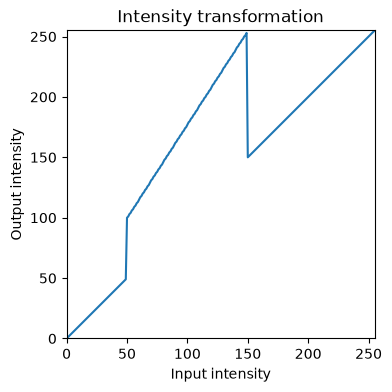

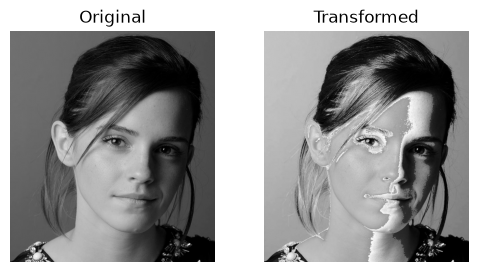

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    """
    im: grayscale image (uint8)
    breakpoints: list/array of (x, y) pairs, sorted by x.
                 Repeat an x value (e.g. (150,255),(150,150)) to create
                 a vertical discontinuity like in Fig. 1a.
    Returns: (transformed_image, lut)
    """
    bp = np.array(breakpoints, dtype=float)
    xs, ys = bp[:, 0], bp[:, 1]
    lut = np.zeros(256, dtype='uint8')

    for i in range(len(bp) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i + 1], ys[i + 1]
        x0i, x1i = int(x0), int(x1)

        if x1i == x0i:          # vertical jump -> nothing to fill in
            continue

        seg = np.linspace(y0, y1, x1i - x0i + 1)
        if i < len(bp) - 2:     # avoid writing the shared boundary twice
            lut[x0i:x1i] = seg[:-1].astype('uint8')
        else:                   # last segment: include the final point (255)
            lut[x0i:x1i + 1] = seg.astype('uint8')

    transformed = cv.LUT(im, lut)
    return transformed, lut


# --- Reproduce the sawtooth shown in Fig. 1a ---
#breakpoints = [(0, 0), (50, 50), (150, 250), (150, 150), (255, 255)]
breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255), (150,150), (255, 255)]


img_orig = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)   # <-- change filename to match your file
img_transformed, lut = intensity_transform(img_orig, breakpoints)

# Plot the transformation curve
plt.figure(figsize=(4, 4))
plt.plot(lut)
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.title('Intensity transformation')
plt.show()

# Side-by-side original vs transformed
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

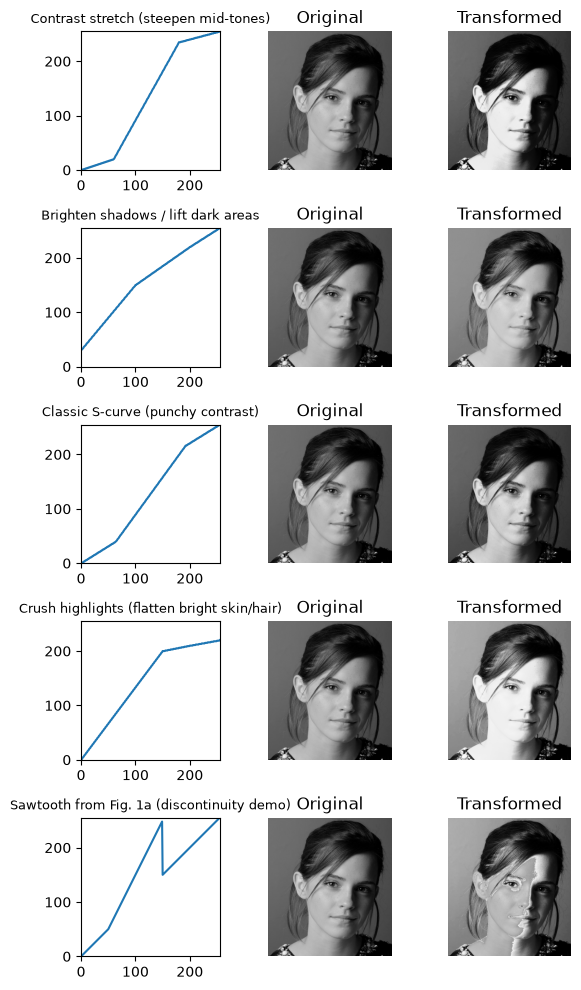

In [9]:
test_breakpoints = {
    "Contrast stretch (steepen mid-tones)": [
        (0, 0), (60, 20), (180, 235), (255, 255)
    ],
    "Brighten shadows / lift dark areas": [
        (0, 30), (100, 150), (200, 220), (255, 255)
    ],
    "Classic S-curve (punchy contrast)": [
        (0, 0), (64, 40), (128, 128), (192, 216), (255, 255)
    ],
    "Crush highlights (flatten bright skin/hair)": [
        (0, 0), (150, 200), (200, 210), (255, 220)
    ],
    "Sawtooth from Fig. 1a (discontinuity demo)": [
        (0, 0), (50, 50), (150, 250), (150, 150), (255, 255)
    ],
}

fig, axes = plt.subplots(len(test_breakpoints), 3, figsize=(6, 2 * len(test_breakpoints)))

for row, (label, bp) in enumerate(test_breakpoints.items()):
    transformed, lut = intensity_transform(img_orig, bp)

    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 2

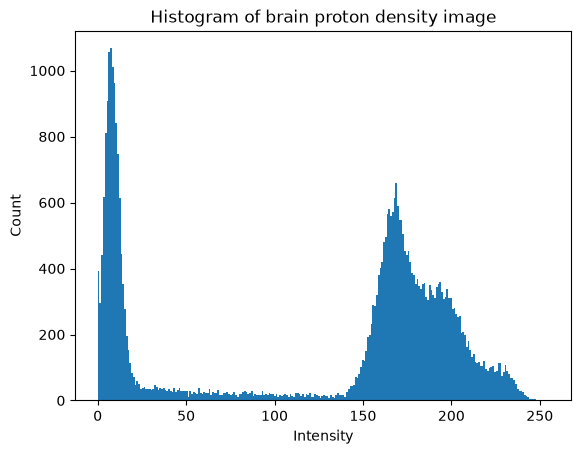

In [10]:
img_orig = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)  # <-- match your filename

plt.figure()
plt.hist(img_orig.ravel(), bins=256, range=(0, 255))
plt.title('Histogram of brain proton density image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

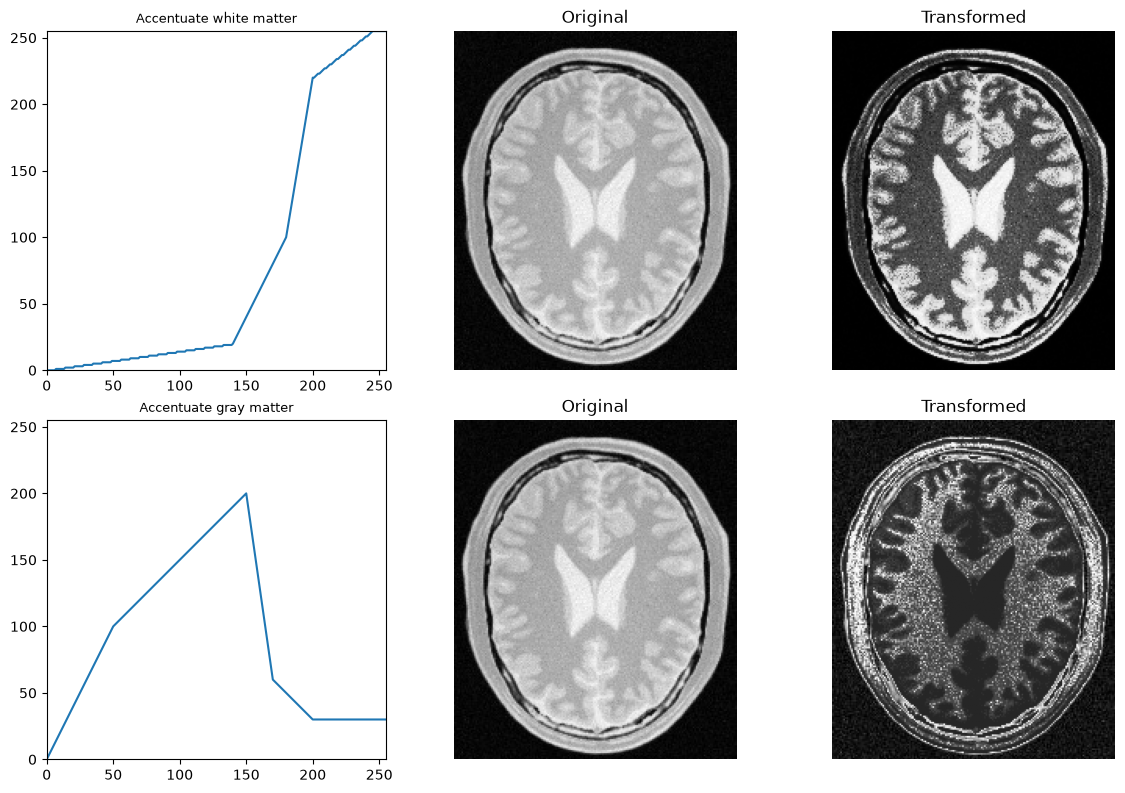

In [ ]:
transforms = {
    "Accentuate white matter": [
        (0, 0), (140, 20), (180, 100), (200, 220), (245, 255), (255, 255)
    ],
    "Accentuate gray matter": [
        (0, 0), (50, 100), (150, 200), (170, 60), (200, 30), (255, 30)
    ],
}

fig, axes = plt.subplots(len(transforms), 3, figsize=(12, 4 * len(transforms)))

for row, (label, bp) in enumerate(transforms.items()):
    transformed, lut = intensity_transform(img_orig, bp)

    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 3

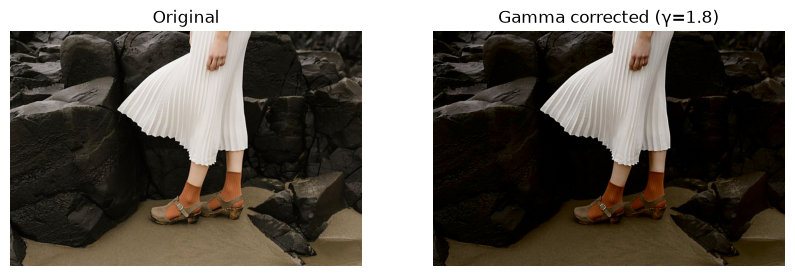

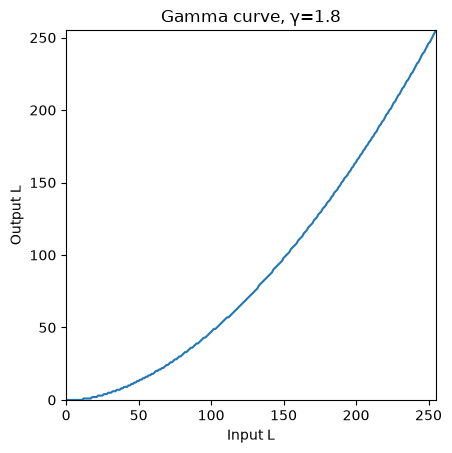

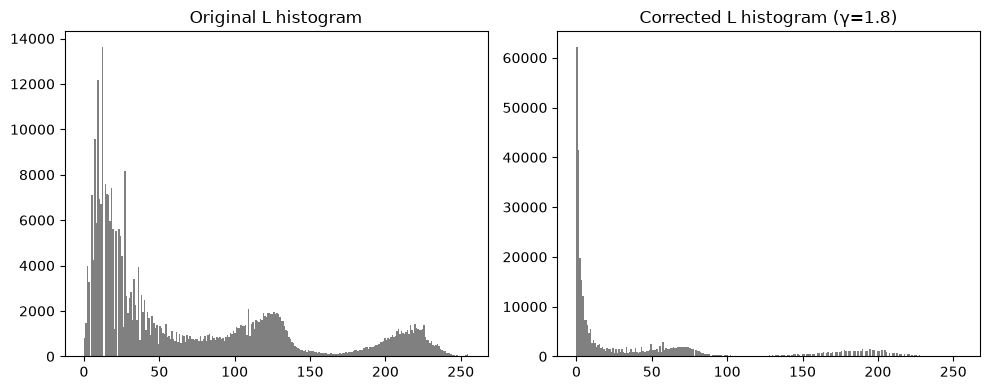

In [14]:
img_bgr = cv.imread('images/q3.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)

gamma = 1.8   # >1 darkens midtones/shadows, <1 brightens them — pick based on your image, state it in report

# Build LUT for the gamma function (0-255 -> 0-255)
lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype='uint8')
L_corrected = cv.LUT(L, lut)

img_lab_corrected = cv.merge([L_corrected, a, b])
img_bgr_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2BGR)

# --- Display original vs corrected ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(img_bgr_corrected, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (γ={gamma})'); axes[1].axis('off')
plt.show()

# --- Gamma curve itself (nice to include in the report) ---
plt.figure()
plt.plot(lut)
plt.xlim(0, 255); plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.xlabel('Input L'); plt.ylabel('Output L')
plt.title(f'Gamma curve, γ={gamma}')
plt.show()

# --- Histograms of L channel before and after ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[1].hist(L_corrected.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ={gamma})')
plt.tight_layout()
plt.show()

### Question 4

#### (a) Split into hue, saturation, and value planes

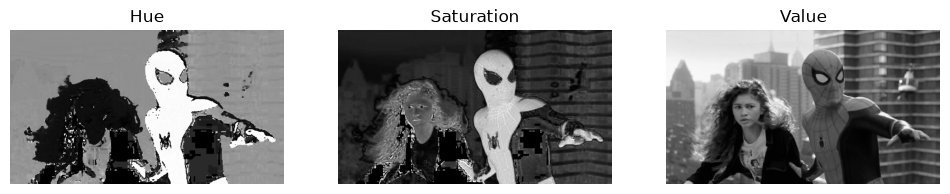

In [15]:
img_bgr = cv.imread('images/q4.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.show()

#### (b) Apply the vibrance transformation to the saturation plane

In [16]:
def vibrance_lut(a, sigma=70):
    x = np.arange(256, dtype=np.float64)
    f = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    f = np.clip(f, 0, 255)
    return f.astype('uint8')

a = 0.6  # placeholder, tuned in part (c)
sigma = 70
lut = vibrance_lut(a, sigma)

s_vibrant = cv.LUT(s, lut)

#### (c) Adjust a and report the value

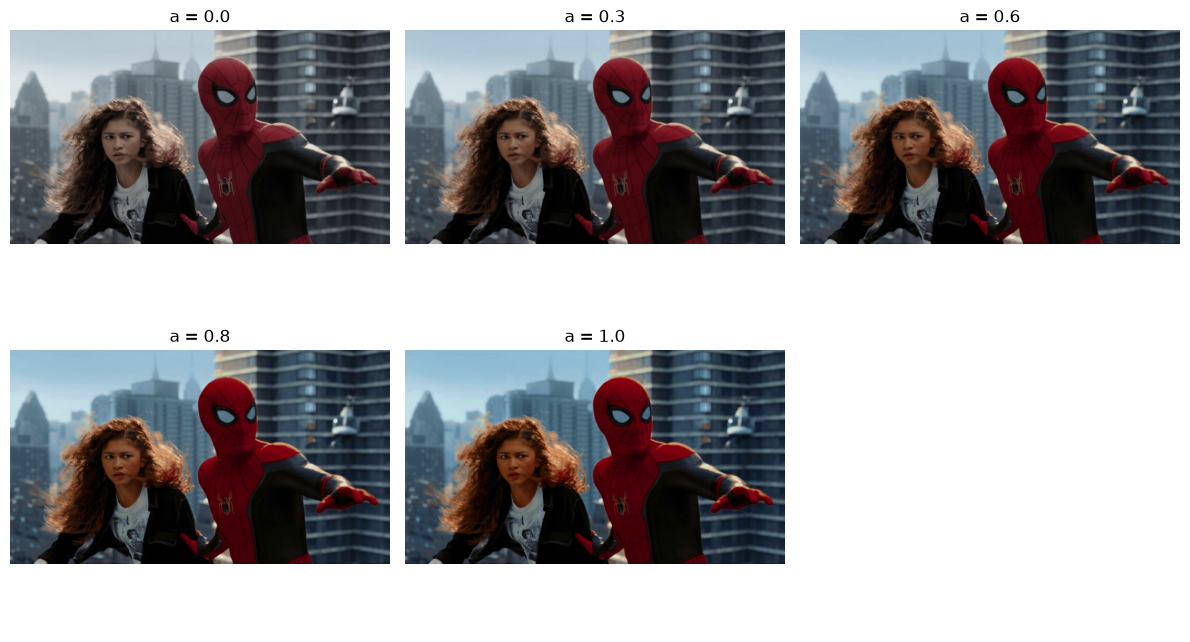

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
a_values = [0.0, 0.3, 0.6, 0.8, 1.0]

for ax, a_test in zip(axes.ravel(), a_values):
    lut_test = vibrance_lut(a_test, sigma)
    s_test = cv.LUT(s, lut_test)
    hsv_test = cv.merge([h, s_test, v])
    bgr_test = cv.cvtColor(hsv_test, cv.COLOR_HSV2BGR)
    ax.imshow(cv.cvtColor(bgr_test, cv.COLOR_BGR2RGB))
    ax.set_title(f'a = {a_test}')
    ax.axis('off')

axes.ravel()[-1].axis('off')  # hide unused subplot if 5 values in a 2x3 grid
plt.tight_layout()
plt.show()

# after visually comparing, set your chosen value:
a = 0.6   # <-- report this number in your write-up, with justification
lut = vibrance_lut(a, sigma)
s_vibrant = cv.LUT(s, lut)

#### (d) Recombine the three planes

In [18]:
img_hsv_vibrant = cv.merge([h, s_vibrant, v])
img_bgr_vibrant = cv.cvtColor(img_hsv_vibrant, cv.COLOR_HSV2BGR)

#### (e) Display original, vibrance-enhanced image, and the intensity transformation

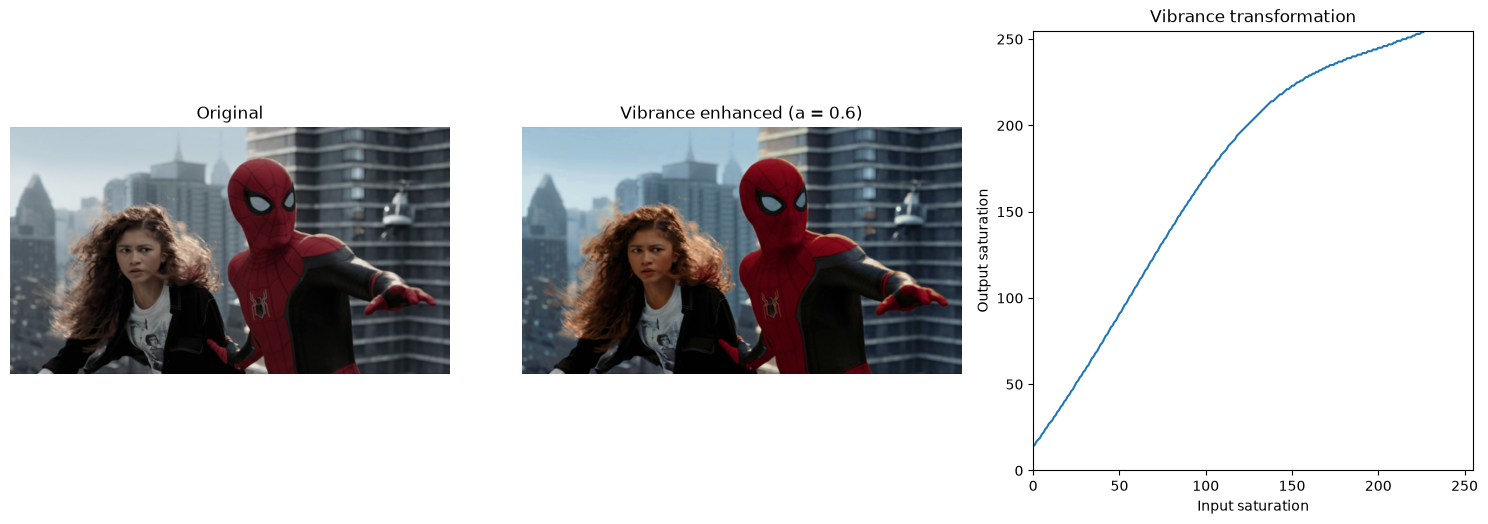

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(img_bgr_vibrant, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a = {a})')
axes[1].axis('off')

axes[2].plot(lut)
axes[2].set_xlim(0, 255); axes[2].set_ylim(0, 255)
axes[2].set_aspect('equal')
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Vibrance transformation')

plt.tight_layout()
plt.show()

### Question 5

Max abs difference vs cv.equalizeHist: 0


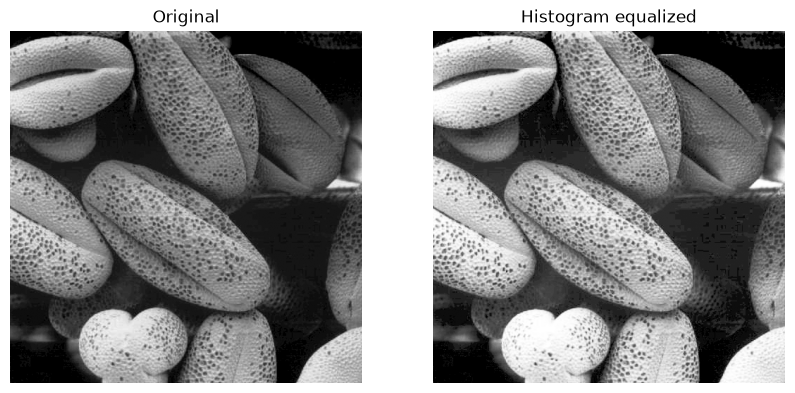

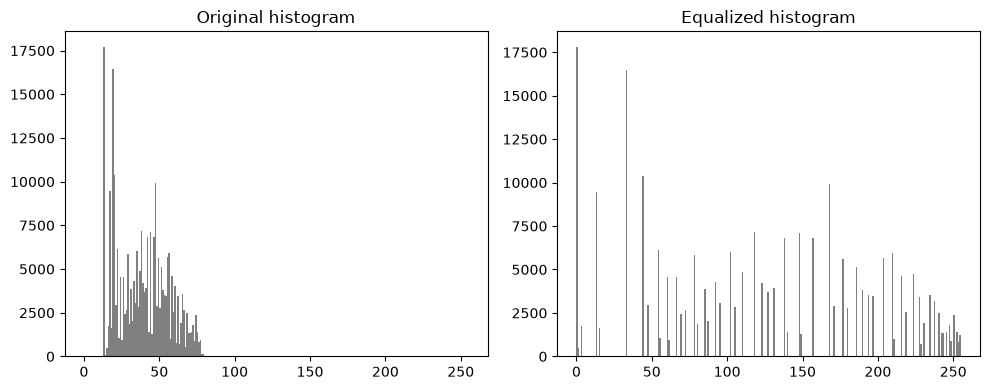

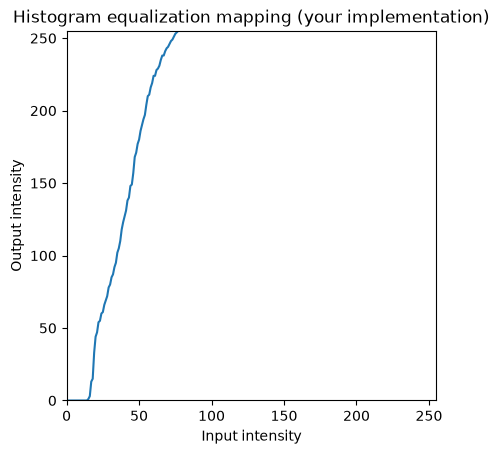

In [21]:
def my_histogram_equalization(img):
    """
    img: single-channel uint8 grayscale image
    Returns: (equalized_image, lut)
    """
    hist = np.bincount(img.ravel(), minlength=256)          # histogram
    cdf = np.cumsum(hist)                                    # cumulative sum
    cdf_min = cdf[cdf > 0].min()                              # smallest nonzero cdf value
    total_pixels = img.size

    # standard histogram equalization formula
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype('uint8')

    equalized = cv.LUT(img, lut)
    return equalized, lut


# --- Load image ---
img_orig = cv.imread('images/q5.tif', cv.IMREAD_GRAYSCALE)  # <-- match your filename

img_eq, lut = my_histogram_equalization(img_orig)

# --- Optional: sanity check against OpenCV's built-in ---
img_eq_cv = cv.equalizeHist(img_orig)
print("Max abs difference vs cv.equalizeHist:", np.max(np.abs(img_eq.astype(int) - img_eq_cv.astype(int))))

# --- Display original vs equalized images ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_eq, cmap='gray')
axes[1].set_title('Histogram equalized'); axes[1].axis('off')
plt.show()

# --- Histograms before and after ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(img_orig.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original histogram')
axes[1].hist(img_eq.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Equalized histogram')
plt.tight_layout()
plt.show()

# --- Optional: the equalization curve (mapping function) itself ---
plt.figure()
plt.plot(lut)
plt.xlim(0, 255); plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.xlabel('Input intensity'); plt.ylabel('Output intensity')
plt.title('Histogram equalization mapping (your implementation)')
plt.show()

### Question 6

#### (a) split image into H/S/V, display in grayscale

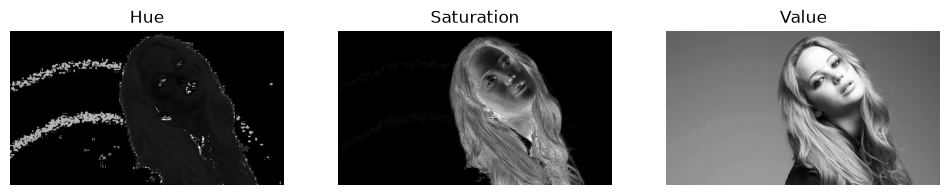

In [22]:
img_bgr = cv.imread('images/q6.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.show()

#### (b) Threshold the right plane to extract the foreground mask

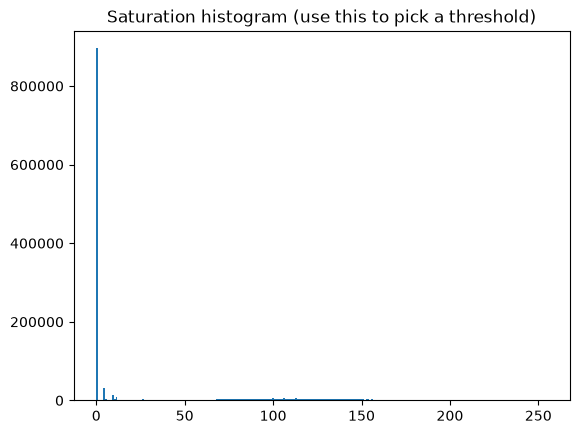

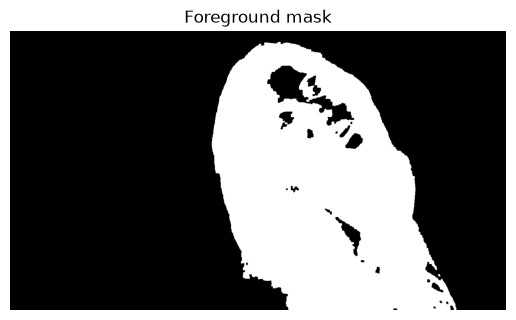

In [23]:
plt.figure()
plt.hist(s.ravel(), bins=256, range=(0, 255))
plt.title('Saturation histogram (use this to pick a threshold)')
plt.show()

thresh_val = 40  # <-- tune based on the histogram above
_, mask = cv.threshold(s, thresh_val, 255, cv.THRESH_BINARY)

# optional cleanup of small noise/holes
kernel = np.ones((5, 5), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

plt.figure()
plt.imshow(mask, cmap='gray')
plt.title('Foreground mask')
plt.axis('off')
plt.show()

#### (c) Obtain the foreground only using cv.bitwise_and, compute its histogram

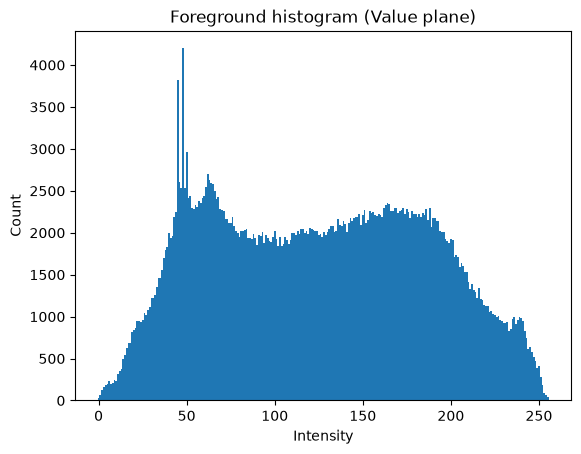

In [24]:
v_foreground = cv.bitwise_and(v, v, mask=mask)

# histogram of foreground only — exclude the masked-out (zero) pixels
fg_pixels = v_foreground[mask > 0]
hist_fg = np.bincount(fg_pixels, minlength=256)

plt.figure()
plt.bar(np.arange(256), hist_fg, width=1)
plt.title('Foreground histogram (Value plane)')
plt.xlabel('Intensity'); plt.ylabel('Count')
plt.show()

#### (d) Cumulative sum of the histogram using np.cumsum

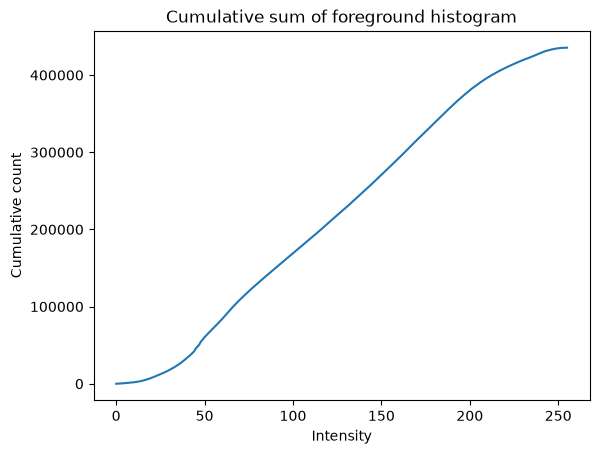

In [25]:
cdf_fg = np.cumsum(hist_fg)

plt.figure()
plt.plot(cdf_fg)
plt.title('Cumulative sum of foreground histogram')
plt.xlabel('Intensity'); plt.ylabel('Cumulative count')
plt.show()

#### (e) Histogram-equalize the foreground

In [26]:
def my_histogram_equalization(pixels, hist, cdf, out_shape):
    cdf_min = cdf[cdf > 0].min()
    total_pixels = pixels.size
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype('uint8')
    equalized = lut[pixels]  # apply LUT
    return equalized.reshape(out_shape), lut

fg_eq_values, lut = my_histogram_equalization(fg_pixels, hist_fg, cdf_fg, fg_pixels.shape)

# put the equalized values back into a full-size image (zeros outside mask)
v_fg_equalized = np.zeros_like(v)
v_fg_equalized[mask > 0] = fg_eq_values

#### (f) Extract background, add with the equalized foreground

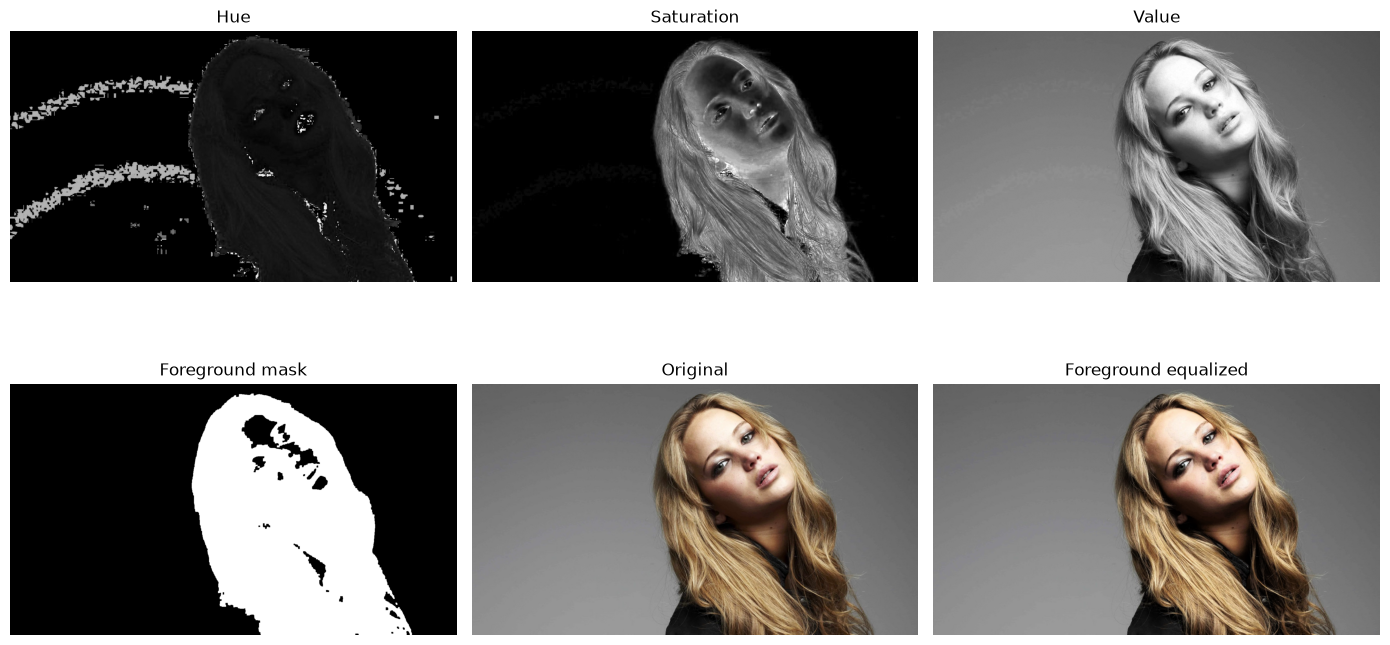

In [27]:
v_background = cv.bitwise_and(v, v, mask=cv.bitwise_not(mask))
v_combined = cv.add(v_background, v_fg_equalized)

img_hsv_result = cv.merge([h, s, v_combined])
img_bgr_result = cv.cvtColor(img_hsv_result, cv.COLOR_HSV2BGR)

# --- Final display: HSV planes, mask, original, result ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0,0].imshow(h, cmap='gray'); axes[0,0].set_title('Hue'); axes[0,0].axis('off')
axes[0,1].imshow(s, cmap='gray'); axes[0,1].set_title('Saturation'); axes[0,1].axis('off')
axes[0,2].imshow(v, cmap='gray'); axes[0,2].set_title('Value'); axes[0,2].axis('off')
axes[1,0].imshow(mask, cmap='gray'); axes[1,0].set_title('Foreground mask'); axes[1,0].axis('off')
axes[1,1].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)); axes[1,1].set_title('Original'); axes[1,1].axis('off')
axes[1,2].imshow(cv.cvtColor(img_bgr_result, cv.COLOR_BGR2RGB)); axes[1,2].set_title('Foreground equalized'); axes[1,2].axis('off')
plt.tight_layout()
plt.show()